<a href="https://colab.research.google.com/github/dee0742/ML-FlyRank-Task/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Content Refresh Opportunity Ranking

This notebook is the reproducible analysis behind the final research paper. It uses simple words, measured results, and a human-in-the-loop decision-support framing.

## 1. Question

**Research question:** Can observable content and search-performance signals rank pages that are currently showing a decline in impressions, so a reviewer can decide which pages to inspect first?

**Decision supported:** prioritize a review queue. A high model score means higher measured decline risk; it does **not** mean a refresh will cause performance to improve.

The target is `is_declining_label = 1` when `trend_direction == "down"`. The model is therefore a ranking aid for observed decline, not a causal model of why a page declined.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

DATA_URL = "https://raw.githubusercontent.com/dee0742/ML-FlyRank-Task/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(DATA_URL)
print("Dataset shape:", df.shape)
assert len(df) == 30000

# The released starter data defines the target from trend_direction.
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)
print("Declining rows:", int(df["is_declining_label"].sum()))
print("Declining rate:", round(df["is_declining_label"].mean(), 4))

Dataset shape: (30000, 44)
Declining rows: 16262
Declining rate: 0.5421


## 2. Data

**Modeling release:** the bundled public-safe starter dataset, `content_refresh_anonymized.csv` — 30,000 content rows and 44 original columns. Each row represents a content item with pseudonymized IDs and aggregated search/engagement signals.

The wider internship warehouse release contains daily performance and dimension/query tables, but this capstone notebook does not claim to model all ~79M warehouse rows. The reproducible model below is based on the 30k starter slice used by the earlier refresh-opportunity pipeline.

**Observed fields used:** keyword context, content properties, 90-day activity totals, availability/recency signals, and derived rates that are available in the released snapshot.

**Excluded:** client/content IDs, `trend_direction`, `trend_pct`, and the target itself. IDs are grouping keys only. The label-derived trend fields are excluded because they directly define the target.

In [2]:
# Audit the data before modeling.
print("Unique clients:", df["client_id"].nunique())
print("Missing word_count:", int(df["word_count"].isna().sum()))
print("Missing search_volume:", int(df["search_volume"].isna().sum()))
print("Trend distribution:")
print(df["trend_direction"].value_counts())

# Keep the label definition visible in the notebook.
assert df["is_declining_label"].sum() == 16262
assert "trend_direction" in df.columns and "trend_pct" in df.columns

Unique clients: 32
Missing word_count: 7699
Missing search_volume: 2468
Trend distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


## 3. Methodology

### Label

`is_declining_label = 1` when `trend_direction == "down"`. In the released starter data, `down` means the most recent 30-day impressions are more than 20% below the previous 30-day impressions.

### Features

The model uses numeric signals such as search volume, content age, impressions/clicks/sessions, CTR, average position, engagement and recency, plus selected categorical content/tier fields. It uses log-transformed traffic totals where supplied by the preparation pipeline.

### Baseline

The transparent baseline combines percentile rank of content staleness (`days_since_last_update`) and search demand (`search_volume`) with equal weights. It is a review-priority rule, not a causal model.

### Validation

A client-grouped 80/20 split is used with a fixed seed. This prevents the same client from appearing in both training and test sets. Precision@20, @50 and @100 are the main ranking metrics because the practical task is to inspect a limited queue.

### Leakage checks

The target, its source fields, and identifiers are removed before fitting. The checks below fail loudly if any forbidden column enters the feature matrix.

In [3]:
NUMERIC_FEATURES = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions", "content_age_days",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct"
]
CATEGORICAL_FEATURES = [
    "competition_level", "content_type", "main_intent", "age_tier", "freshness_tier",
    "word_count_tier", "impression_tier", "position_tier"
]

feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
missing_features = [c for c in feature_cols if c not in df.columns]
assert not missing_features, f"Missing feature columns: {missing_features}"

forbidden = {"is_declining_label", "trend_direction", "trend_pct", "content_id", "client_id"}
assert not forbidden.intersection(feature_cols), forbidden.intersection(feature_cols)

X = df[feature_cols].copy()
y = df["is_declining_label"].copy()
groups = df["client_id"].copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

overlap = set(groups.iloc[train_idx]).intersection(set(groups.iloc[test_idx]))
assert len(overlap) == 0
print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Client overlap:", len(overlap))
print("Train decline rate:", round(y_train.mean(), 4))
print("Test decline rate:", round(y_test.mean(), 4))

Train rows: 23837
Test rows: 6163
Client overlap: 0
Train decline rate: 0.5501
Test decline rate: 0.511


In [4]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipe, NUMERIC_FEATURES),
    ("categorical", categorical_pipe, CATEGORICAL_FEATURES)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
        min_samples_leaf=2
    ))
])
model.fit(X_train, y_train)
model_scores = model.predict_proba(X_test)[:, 1]

# Transparent baseline, evaluated on exactly the same test rows.
staleness = df.iloc[test_idx]["days_since_last_update"].rank(pct=True, na_option="bottom")
demand = df.iloc[test_idx]["search_volume"].rank(pct=True, na_option="bottom")
baseline_scores = (0.5 * staleness + 0.5 * demand).to_numpy()

def precision_at_k(y_true, scores, k):
    order = np.argsort(-np.asarray(scores))[:k]
    return float(np.asarray(y_true)[order].mean())

results = pd.DataFrame({
    "Method": ["Random Forest", "Staleness + demand baseline"],
    "ROC AUC": [roc_auc_score(y_test, model_scores), roc_auc_score(y_test, baseline_scores)],
    "Average precision": [average_precision_score(y_test, model_scores), average_precision_score(y_test, baseline_scores)],
    "Precision@20": [precision_at_k(y_test, model_scores, 20), precision_at_k(y_test, baseline_scores, 20)],
    "Precision@50": [precision_at_k(y_test, model_scores, 50), precision_at_k(y_test, baseline_scores, 50)],
    "Precision@100": [precision_at_k(y_test, model_scores, 100), precision_at_k(y_test, baseline_scores, 100)],
})
print(results.round(3).to_string(index=False))
print("Test-set base rate:", round(y_test.mean(), 3))

                     Method  ROC AUC  Average precision  Precision@20  Precision@50  Precision@100
              Random Forest    0.616              0.607           0.7          0.64           0.62
Staleness + demand baseline    0.440              0.470           0.4          0.38           0.38
Test-set base rate: 0.511


## 4. Results (vs baseline)

The table below is generated from the same client-held-out test set for both methods. The base rate is shown so Precision@K is interpreted against the prevalence of decline in the test set.

**Interpretation rule:** a higher Precision@K means the method placed more observed declining pages near the top of the review queue on this held-out split. It does not show that the model causes improvement after a refresh.

In [5]:
# Add the test-set base rate and model lift for easy paper reuse.
base_rate = y_test.mean()
results["Precision@50 lift vs base rate"] = results["Precision@50"] / base_rate
print(results.round(3).to_string(index=False))

# A compact headline generated from the measured result.
rf_p50 = results.loc[results["Method"] == "Random Forest", "Precision@50"].iloc[0]
base_p50 = results.loc[results["Method"] == "Staleness + demand baseline", "Precision@50"].iloc[0]
print(f"Random Forest Precision@50: {rf_p50:.3f}")
print(f"Baseline Precision@50: {base_p50:.3f}")
print(f"Test base rate: {base_rate:.3f}")

                     Method  ROC AUC  Average precision  Precision@20  Precision@50  Precision@100  Precision@50 lift vs base rate
              Random Forest    0.616              0.607           0.7          0.64           0.62                           1.253
Staleness + demand baseline    0.440              0.470           0.4          0.38           0.38                           0.744
Random Forest Precision@50: 0.640
Baseline Precision@50: 0.380
Test base rate: 0.511


## 5. Limitations

- This notebook models the 30k starter slice, not a fresh re-analysis of every row in the ~79M-row warehouse.
- The target is an observed trend rule. It does not identify the cause of a decline.
- A cross-sectional snapshot can contain cohort and client differences that are not fully captured by a single grouped split.
- Precision@K measures ranking quality for review prioritization; it does not measure business impact, traffic recovered, or ROI.
- The model should support human review, not automatically publish, delete, redirect, or rewrite content.
- Results can change with a different release, time window, feature contract, split, or random seed. The reported numbers should therefore be described as measured on this validation setup, not as universal performance.

## 6. Ranked recommendations

The action playbook turns model risk and visible opportunity signals into reviewer-facing actions. The ranking is a decision-support queue.

1. **Review high model-risk pages first.** Start with pages receiving the highest model probability because this is the learned ranking signal being evaluated.
2. **Prioritize pages where decline and demand are both visible.** These pages combine an observed decline signal with evidence that the content has search demand, making manual review more actionable.
3. **Use CTR and engagement reason codes for diagnosis.** Low CTR or engagement can tell the reviewer what to inspect, but these codes are descriptive signals rather than proof of cause.
4. **Keep a monitor group.** Not every page needs immediate intervention; lower-priority items can remain in a monitoring queue.

These recommendations describe what to review first. They do not claim that a particular refresh action will improve performance.

In [8]:
# Build a reviewer-friendly ranked queue on the held-out test set.
queue = df.iloc[test_idx][[
    "content_id", "client_id", "days_since_last_update", "search_volume",
    "content_type", "main_intent", "trend_direction", "ctr",
    "engagement_rate", "impressions_90d"
]].copy()
queue["model_probability"] = model_scores
queue["baseline_score"] = baseline_scores
queue["declining_with_demand"] = ((queue["trend_direction"] == "down") & (queue["search_volume"].fillna(0) >= 500))
queue["low_ctr_visible_page"] = ((queue["ctr"].fillna(0) < queue["ctr"].median()) & (queue["impressions_90d"].fillna(0) >= 100)) if "impressions_90d" in df.columns else False
queue["low_engagement_visible_page"] = queue["engagement_rate"].fillna(0) < queue["engagement_rate"].median()

queue["action_score"] = 100 * queue["model_probability"]
queue["action"] = np.select(
    [queue["declining_with_demand"] & (queue["low_ctr_visible_page"]),
     queue["declining_with_demand"],
     queue["model_probability"] >= 0.5],
    ["refresh_and_review_ctr", "refresh", "review_diagnostic"],
    default="monitor"
)
queue = queue.sort_values("action_score", ascending=False).reset_index(drop=True)
queue["rank"] = queue.index + 1
print(queue[["rank","content_id","model_probability","action","days_since_last_update","search_volume","trend_direction"]].head(20).to_string(index=False))

 rank           content_id  model_probability            action  days_since_last_update  search_volume trend_direction
    1 content_2ba626fea4d6           0.958143 review_diagnostic                     104           10.0              up
    2 content_e988c1699454           0.956931 review_diagnostic                     104           30.0            down
    3 content_9ac61c04930e           0.953602 review_diagnostic                     104           10.0            down
    4 content_7a6cb4857fe6           0.947098 review_diagnostic                      20            0.0            down
    5 content_569475b335ab           0.944429 review_diagnostic                     104           10.0            down
    6 content_6607847e4454           0.941853 review_diagnostic                     104            0.0            down
    7 content_98aa0aecb1d9           0.938223 review_diagnostic                     104           10.0            down
    8 content_7766ffacdcfa           0.929210 re

## 7. Artifacts the paper embeds

The following charts are generated from the validation and queue outputs. Each chart has one job: show ranking performance or the shape of the final decision-support queue.

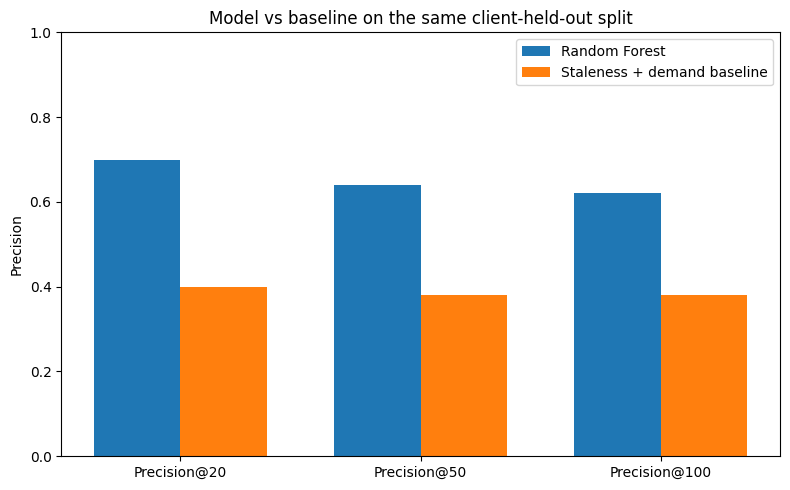

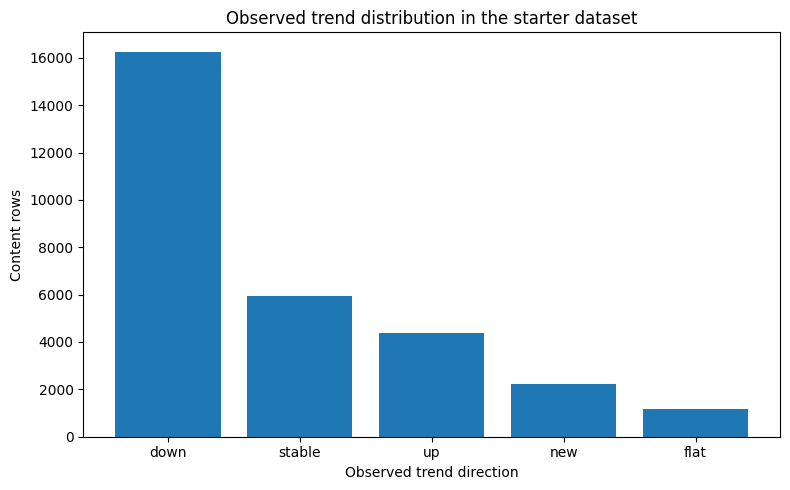

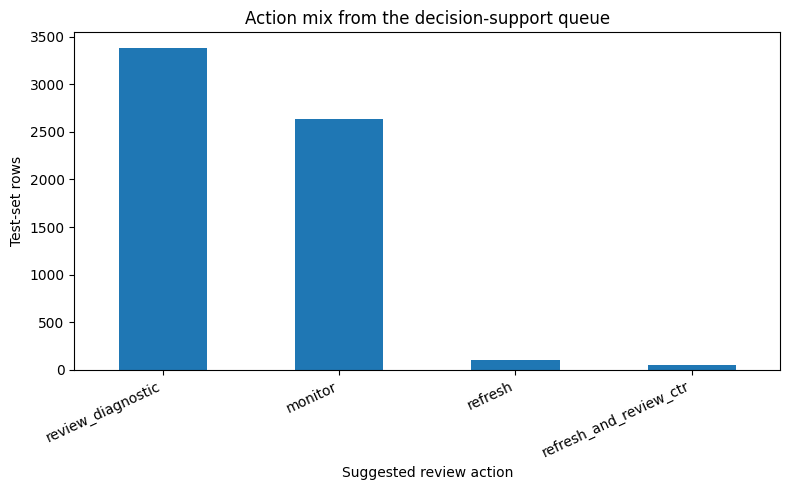

In [9]:
# Artifact 1: Precision@K comparison.
k_values = [20, 50, 100]
rf_vals = [precision_at_k(y_test, model_scores, k) for k in k_values]
base_vals = [precision_at_k(y_test, baseline_scores, k) for k in k_values]

x = np.arange(len(k_values))
width = 0.36
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, rf_vals, width, label="Random Forest")
plt.bar(x + width/2, base_vals, width, label="Staleness + demand baseline")
plt.xticks(x, [f"Precision@{k}" for k in k_values])
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.title("Model vs baseline on the same client-held-out split")
plt.legend()
plt.tight_layout()
plt.show()

# Artifact 2: observed trend distribution.
plt.figure(figsize=(8, 5))
counts = df["trend_direction"].value_counts()
plt.bar(counts.index, counts.values)
plt.ylabel("Content rows")
plt.xlabel("Observed trend direction")
plt.title("Observed trend distribution in the starter dataset")
plt.tight_layout()
plt.show()

# Artifact 3: action mix in the held-out review queue.
plt.figure(figsize=(8, 5))
queue["action"].value_counts().plot(kind="bar")
plt.ylabel("Test-set rows")
plt.xlabel("Suggested review action")
plt.title("Action mix from the decision-support queue")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Reproducibility

- Dataset: bundled `data/raw/content_refresh_anonymized.csv`
- Split: `GroupShuffleSplit`, 80/20, `random_state=42`, grouped by `client_id`
- Model: `RandomForestClassifier`, 300 trees, `random_state=42`, `min_samples_leaf=2`
- Main ranking metrics: Precision@20, Precision@50, Precision@100
- Leakage exclusions are asserted in code.

The final paper should link to this notebook and the repository so another reader can inspect the implementation.

# ML-12 closing cells

## 5-minute demo outline

**0:00–0:45 — Problem:** explain that the task is to prioritize content for human review when impressions are declining.

**0:45–1:30 — Data:** introduce the 30k public-safe starter slice and explain the target rule.

**1:30–2:30 — Method:** show the client-grouped split, the transparent staleness+demand baseline, and the Random Forest model.

**2:30–3:30 — Results:** show Precision@20/@50/@100 from the same held-out split and compare them with the baseline and test-set base rate.

**3:30–4:20 — Action playbook:** show the ranked queue and reason/action signals.

**4:20–5:00 — Honest framing:** explain leakage checks, limitations, and why the output is decision support rather than an automatic content decision.

## Social-post cut

**Built a content-refresh ranking system using a 30,000-row public-safe search dataset. I compared a transparent staleness+demand baseline with a Random Forest model using a client-grouped validation split and Precision@K metrics. The final output is a reviewer-friendly action queue, with explicit leakage checks and honest limits.**

## Employer-facing 3-sentence summary

I built a machine-learning ranking system that prioritizes content items for human review when search impressions are declining. I compared a simple staleness+demand baseline with a Random Forest model using a client-held-out split and ranking metrics such as Precision@20, @50, and @100. I also added leakage checks, interpretable action signals, validation charts, and a reproducible reviewer queue.

## Final self-check

- [x] Question, data, methodology, results, limitations, recommendations, and artifacts are filled.
- [x] Code recalculates the reported metrics instead of hard-coding them.
- [x] Client/content IDs are not model features.
- [x] Label-derived trend fields are not model features.
- [x] Validation uses a client-grouped split.
- [x] Claims are framed as observed/measured/decision-support.
- [ ] Run **Runtime → Run all** in Colab and confirm every cell completes.
- [ ] Deploy the separate research paper with all 9 required sections.
- [ ] Put the exact deployed paper URL in `submission/paper_url.txt`.